# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import math

# Graphiz Helper Function for Gradient Flow Graph

In [2]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

# Required Classes for Micrograd

### Value Class which acts as a Data structure

In [8]:
class Value:
    # Constructor
    def __init__(self, data: float, label: str="", _op: str="", _children: tuple=()):
        # public members
        self.data = data
        self.label = label
        self.grad = 0.0
        # protected members
        self._op = _op
        self._backward = lambda: None
        self._prev = set(_children)

    # special/dunder method for returning the string representation of an object 
    def __repr__(self):
        return f"Value.data = {self.data}"

    # Micro methods for algebraic operations

    # addition
    def __add__(self, other):
        # type casting for edge case Value+int/float
        other = Value(other) if not isinstance(other, Value) else other

        # performing addition
        out = Value((self.data + other.data), _op="+", _children=(self, other))

        # calculating gradient for addition operation => gradient of output flows back as it is to operands
        # storing the calculation as a callback function for back-propagation
        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0

        # setting the callback as the object's _backward function
        out._backward = _backward

        return out

    # reverse addition to handle the edge case int/float+Value
    def __radd__(self, other):
        # here the self and other are exchanged with each other
        return self + other

    # multiplication
    def __mul__(self, other):
        # type casting for edge case Value*int/float
        other = Value(other) if not isinstance(other, Value) else other

        # performing multiplication
        out = Value((self.data * other.data), _op="*", _children=(self, other))

        # calculating gradient for multiplication operation => gradient of output flows back to operands and multiplied by the other operand's data
        # storing the calculation as a callback function for back-propagation
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data

        # setting the callback as the object's _backward function
        out._backward = _backward

        return out

    # reverse multiplication to handle the edge case int/float*Value
    def __rmul__(self, other):
        # here the self and other are exchanged with each other
        return self * other

    # exponentiation
    def __pow__(self, other):
        # making sure that the other is never a Value object
        assert isinstance(other, (int, float))

        # performing exponentiation
        out = Value((self.data ** other), _op=f"pow({other})", _children=(self,))

        # calculating gradient for exponentiation operation 
        # storing the calculation as a callback function for back-propagation
        def _backward():
            self.grad += out.grad * other * (self.data ** (other - 1))

        # setting the callback as the object's _backward function
        out._backward = _backward

        return out

    # subtraction
    def __sub__(self, other):
        return self + (-1 * other) # using the already built methods

    # reverse subtraction to handle the edge case int/float-Value
    def __rsub__(self, other):
        # here the self and other are exchanged with each other
        return (self * -1) + other

    def __truediv__(self, other):
        # type casting for edge case Value*int/float
        other = Value(other) if not isinstance(other, Value) else other

        # using the multiplication for division
        return self * (other ** -1)

    def __rtruediv__(self, other):
        # here the self and other are exchanged with each other
        return (self ** -1) * other

    # now implementing activation functions i.e. relu, sigmoid, and tanh

    # tanh implementation
    def tanh(self):
        out = Value((math.tanh(self.data)), _op="tanh", _children=(self,))

        def _backward():
            self.grad += (1 - out.data**2) * out.grad

        out._backward = _backward

        return out

    # relu implementation
    def relu(self):
        out = Value(max(0, self.data), _op="relu", _children=(self,))

        def _backward():
            self.grad += (self.data > 0) * out.grad

        out._backward = _backward

        return out

    # sigmoid implementation
    def sigmoid(self):
        z = 1 / (1 + math.exp(-self.data))

        out = Value(z, _op="sigmoid", _children=(self,))

        def _backward():
            self.grad += z * (1 - z) * out.grad

        out._backward = _backward

        return out

    # now implementing the main backward function with topological sorting
    def backward(self):
        nodes: list[Value] = [] # holds the soreted Value nodes
        visited = set()

        # topological sorting
        def topo_sort(node: Value):
            if node not in visited:
                visited.add(node)
                for child in node._prev:
                    topo_sort(child)
                nodes.append(node)

        # initializing last neuron's gradient to 1.0
        self.grad = 1.0
        topo_sort(self)

        # calling the _backward callback for every node starting from the last one
        for node in reversed(nodes):
            node._backward()

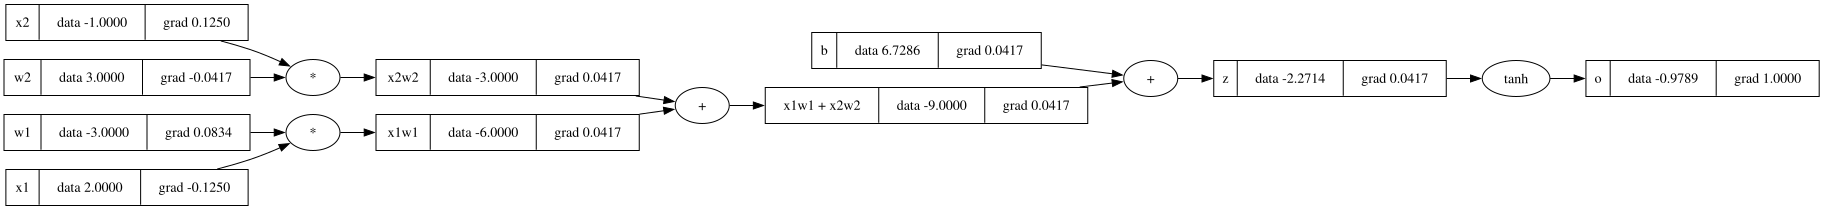

In [10]:
# inputs
x1 = Value(2.0, label="x1")
x2 = Value(-1.0, label="x2")

# weights and bias
w1 = Value(-3.0, label="w1")
w2 = Value(3.0, label="w2")
b = Value(6.7286, label="b")

# z = x1*w1 + x2*w2 + b
x1w1 = x1 * w1
x1w1.label = "x1w1"
x2w2 = x2 * w2
x2w2.label = "x2w2"

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1w1 + x2w2"

z = x1w1x2w2 + b
z.label = "z"

# applying the tanh activation function (o = z.tanh())
o = z.tanh()
o.label = "o"

o.backward()

draw_dot(o)

### Neuron Class which is a singular unit in a Neural Net

In [ ]:
class Neuron:
    def __init__(self):
        pass

### Layer class which holds 'n' number of Neurons

In [ ]:
class Layer:
    def __init__(self):
        pass

### Multi-Layer Perceptron class

In [ ]:
class MLP:
    def __init__(self):
        pass

# Testing the MLP